#**Modul 5 - CUDA GPU**
Fajira Zahara

24343033

202523430063 :INF.62.0022

In [ ]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      2
  On-line CPU(s) list:       0,1
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.00GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      1
    Socket(s):               1
    Stepping:                3
    BogoMIPS:                4000.40
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   

In [ ]:
!nvidia-smi

Thu Jun 11 05:21:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


# Modul 5: GPU Computing Dasar – CUDA
## Langkah 1: Setup dan Verifikasi Lingkungan


In [ ]:
import subprocess
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
os.makedirs("cuda_files", exist_ok=True)
print("Folder cuda_files berhasil dibuat")

Folder cuda_files berhasil dibuat


## Langkah 2: CPU Serial – Baseline

In [ ]:
%%writefile cuda_files/vector_add_cpu.cpp

#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <cmath>

void vector_add_cpu(float* A, float* B, float* C, int N){
    for(int i=0;i<N;i++)
        C[i]=A[i]+B[i];
}

int main(int argc,char* argv[]){
    int N=(argc>1)?atoi(argv[1]):10000000;

    std::vector<float> A(N),B(N),C(N);

    srand(42);

    for(int i=0;i<N;i++){
        A[i]=(float)rand()/RAND_MAX;
        B[i]=(float)rand()/RAND_MAX;
    }

    auto t0=std::chrono::high_resolution_clock::now();

    vector_add_cpu(A.data(),B.data(),C.data(),N);

    auto t1=std::chrono::high_resolution_clock::now();

    double ms=
    std::chrono::duration<double,std::milli>(t1-t0).count();

    printf("N=%d TIME_MS=%.4f\n",N,ms);

    return 0;
}

Writing cuda_files/vector_add_cpu.cpp


In [ ]:
!g++ -O2 cuda_files/vector_add_cpu.cpp -o cuda_files/vec_cpu

In [ ]:
!./cuda_files/vec_cpu 10000000

N=10000000 TIME_MS=12.5757


## Langkah 3: CPU dengan OpenMP (Parallel Baseline)

In [ ]:
%%writefile cuda_files/vector_add_openmp.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <cmath>
#include <omp.h>

int main(int argc, char* argv[]) {
    int N = (argc>1)?atoi(argv[1]):10000000;
    int T = (argc>2)?atoi(argv[2]):4;
    std::vector<float> A(N), B(N), C(N);
    srand(42);
    for (int i=0;i<N;i++){A[i]=(float)rand()/RAND_MAX;B[i]=(float)rand()/RAND_MAX;}
    omp_set_num_threads(T);
    auto t0 = std::chrono::high_resolution_clock::now();
    #pragma omp parallel for
    for (int i=0;i<N;i++) C[i]=A[i]+B[i];
    auto t1 = std::chrono::high_resolution_clock::now();
    double ms = std::chrono::duration<double,std::milli>(t1-t0).count();
    bool ok=true;
    for(int i=0;i<10;i++) if(fabs(C[i]-(A[i]+B[i]))>1e-6){ok=false;break;}
    float bw=(3.0f*N*sizeof(float))/(ms/1000.0f)/1e9;
    printf("N=%d THREADS=%d TIME_MS=%.4f BW=%.4f CORRECT=%d\n",N,T,ms,bw,(int)ok);
    return 0;
}


Writing cuda_files/vector_add_openmp.cpp


In [ ]:
!g++ -O2 -fopenmp cuda_files/vector_add_openmp.cpp -o cuda_files/vec_omp

In [ ]:
!./cuda_files/vec_omp 10000000 4

N=10000000 THREADS=4 TIME_MS=12.1783 BW=9.8536 CORRECT=1


## Langkah 4: CUDA Basic – GPU Kernel

In [ ]:
%%writefile cuda_files/vector_add_cuda.cu
#include <iostream>
#include <cuda_runtime.h>
#include <cstdlib>
#include <cmath>

#define CHECK(call) { \
    cudaError_t e = call; \
    if (e != cudaSuccess) { \
        fprintf(stderr, "CUDA error %s:%d: %s\n", \
                __FILE__, __LINE__, cudaGetErrorString(e)); \
        exit(1); \
    } \
}

// ─── CUDA Kernel ─────────────────────────────────
__global__ void vec_add(float* A, float* B, float* C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) C[idx] = A[idx] + B[idx];
}

int main(int argc, char* argv[]) {
    int N   = (argc>1) ? atoi(argv[1]) : 10000000;
    int TPB = (argc>2) ? atoi(argv[2]) : 256;  // threads per block
    size_t sz = N * sizeof(float);

    // ─── Alokasi Host ────────────────────────────
    float *h_A=new float[N], *h_B=new float[N], *h_C=new float[N];
    srand(42);
    for(int i=0;i<N;i++){h_A[i]=(float)rand()/RAND_MAX;h_B[i]=(float)rand()/RAND_MAX;}

    // ─── Alokasi Device ──────────────────────────
    float *d_A,*d_B,*d_C;
    CHECK(cudaMalloc(&d_A,sz)); CHECK(cudaMalloc(&d_B,sz)); CHECK(cudaMalloc(&d_C,sz));

    // ─── CUDA Events untuk timing ────────────────
    cudaEvent_t ev0,ev1; CHECK(cudaEventCreate(&ev0)); CHECK(cudaEventCreate(&ev1));
    float t_htod, t_kernel, t_dtoh;

    // HtoD transfer
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(d_A,h_A,sz,cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B,h_B,sz,cudaMemcpyHostToDevice));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_htod,ev0,ev1));

    // Kernel launch
    int blocks = (N+TPB-1)/TPB;
    CHECK(cudaEventRecord(ev0));
    vec_add<<<blocks,TPB>>>(d_A,d_B,d_C,N);
    CHECK(cudaGetLastError());
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_kernel,ev0,ev1));

    // DtoH transfer
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(h_C,d_C,sz,cudaMemcpyDeviceToHost));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_dtoh,ev0,ev1));

    float total = t_htod + t_kernel + t_dtoh;
    bool ok=true; for(int i=0;i<10;i++) if(fabs(h_C[i]-(h_A[i]+h_B[i]))>1e-6){ok=false;break;}

    printf("N=%d TPB=%d BLOCKS=%d HTOD=%.4f KERNEL=%.4f DTOH=%.4f TOTAL=%.4f CORRECT=%d\n",
           N,TPB,blocks,t_htod,t_kernel,t_dtoh,total,(int)ok);

    delete[]h_A;delete[]h_B;delete[]h_C;
    CHECK(cudaFree(d_A));CHECK(cudaFree(d_B));CHECK(cudaFree(d_C));
    CHECK(cudaEventDestroy(ev0));CHECK(cudaEventDestroy(ev1));
    return 0;
}

Overwriting cuda_files/vector_add_cuda.cu


In [ ]:
!nvcc -O2 -std=c++11 cuda_files/vector_add_cuda.cu -o cuda_files/vec_cuda
!./cuda_files/vec_cuda 10000000 256   # 10M elemen, 256 thread per block


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
N=10000000 TPB=256 BLOCKS=39063 HTOD=18.2875 KERNEL=101.6488 DTOH=26.0766 TOTAL=146.0129 CORRECT=1


## Langkah 5: CUDA Pinned Memory – Transfer Lebih Cepat

In [ ]:
%%writefile cuda_files/vector_add_pinned.cu
#include <iostream>
#include <cuda_runtime.h>
#include <cstdlib>
#include <cmath>

#define CHECK(call) { \
    cudaError_t e = call; \
    if (e != cudaSuccess) { \
        fprintf(stderr, "CUDA error %s:%d: %s\n", \
                __FILE__, __LINE__, cudaGetErrorString(e)); \
        exit(1); \
    } \
}

__global__ void vec_add(float* A, float* B, float* C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) C[idx] = A[idx] + B[idx];
}

int main(int argc, char* argv[]) {
    int N   = (argc>1) ? atoi(argv[1]) : 10000000;
    int TPB = (argc>2) ? atoi(argv[2]) : 256;
    size_t sz = N * sizeof(float);

    // ─── Pinned memory (page-locked) ─────────────
    float *h_A, *h_B, *h_C;
    CHECK(cudaHostAlloc(&h_A, sz, cudaHostAllocDefault));
    CHECK(cudaHostAlloc(&h_B, sz, cudaHostAllocDefault));
    CHECK(cudaHostAlloc(&h_C, sz, cudaHostAllocDefault));
    srand(42);
    for(int i=0;i<N;i++){h_A[i]=(float)rand()/RAND_MAX;h_B[i]=(float)rand()/RAND_MAX;}

    float *d_A,*d_B,*d_C;
    CHECK(cudaMalloc(&d_A,sz)); CHECK(cudaMalloc(&d_B,sz)); CHECK(cudaMalloc(&d_C,sz));

    cudaEvent_t ev0,ev1; CHECK(cudaEventCreate(&ev0)); CHECK(cudaEventCreate(&ev1));
    float t_htod, t_kernel, t_dtoh;

    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(d_A,h_A,sz,cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B,h_B,sz,cudaMemcpyHostToDevice));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_htod,ev0,ev1));

    int blocks=(N+TPB-1)/TPB;
    CHECK(cudaEventRecord(ev0));
    vec_add<<<blocks,TPB>>>(d_A,d_B,d_C,N);
    CHECK(cudaGetLastError());
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_kernel,ev0,ev1));

    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(h_C,d_C,sz,cudaMemcpyDeviceToHost));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_dtoh,ev0,ev1));

    float total=t_htod+t_kernel+t_dtoh;
    bool ok=true; for(int i=0;i<10;i++) if(fabs(h_C[i]-(h_A[i]+h_B[i]))>1e-6){ok=false;break;}
    printf("N=%d TPB=%d HTOD=%.4f KERNEL=%.4f DTOH=%.4f TOTAL=%.4f CORRECT=%d\n",
           N,TPB,t_htod,t_kernel,t_dtoh,total,(int)ok);

    CHECK(cudaFreeHost(h_A)); CHECK(cudaFreeHost(h_B)); CHECK(cudaFreeHost(h_C));
    CHECK(cudaFree(d_A)); CHECK(cudaFree(d_B)); CHECK(cudaFree(d_C));
    CHECK(cudaEventDestroy(ev0)); CHECK(cudaEventDestroy(ev1));
    return 0;
}


Overwriting cuda_files/vector_add_pinned.cu


In [ ]:
!nvcc -O2 -std=c++11 cuda_files/vector_add_pinned.cu -o cuda_files/vec_pinned
!./cuda_files/vec_pinned 10000000 256


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
N=10000000 TPB=256 HTOD=6.6067 KERNEL=0.7845 DTOH=3.0697 TOTAL=10.4609 CORRECT=1


## Langkah 6: Eksperimen Otomatis – Variasi Ukuran Data

In [ ]:
def parse_cpu(out):
    d = {}
    for tok in out.split():
        if '=' in tok:
            k, v = tok.split('=')
            d[k] = v
    return d

def parse_cuda(out):
    d = {}
    for tok in out.split():
        if '=' in tok:
            k, v = tok.split('=')
            d[k] = v
    return d

sizes = [1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]

results = []

for N in sizes:

    row = {'N': N}

    # ==========================
    # CPU SERIAL
    # ==========================
    r = subprocess.run(
        f'./cuda_files/vec_cpu {N}',
        shell=True,
        capture_output=True,
        text=True
    )

    d = parse_cpu(r.stdout)

    row['cpu_ms'] = float(d.get('TIME_MS', 0))

    # ==========================
    # OPENMP (4 THREAD)
    # ==========================
    r = subprocess.run(
        f'./cuda_files/vec_omp {N} 4',
        shell=True,
        capture_output=True,
        text=True
    )

    d = parse_cpu(r.stdout)

    row['omp_ms'] = float(d.get('TIME_MS', 0))

    # ==========================
    # CUDA BASIC
    # ==========================
    r = subprocess.run(
        f'./cuda_files/vec_cuda {N} 256',
        shell=True,
        capture_output=True,
        text=True
    )

    d = parse_cuda(r.stdout)

    row['cuda_htod']   = float(d.get('HTOD', 0))
    row['cuda_kernel'] = float(d.get('KERNEL', 0))
    row['cuda_dtoh']   = float(d.get('DTOH', 0))
    row['cuda_total']  = float(d.get('TOTAL', 0))

    # ==========================
    # CUDA PINNED MEMORY
    # ==========================
    r = subprocess.run(
        f'./cuda_files/vec_pinned {N} 256',
        shell=True,
        capture_output=True,
        text=True
    )

    d = parse_cuda(r.stdout)

    row['pinned_htod']   = float(d.get('HTOD', 0))
    row['pinned_kernel'] = float(d.get('KERNEL', 0))
    row['pinned_dtoh']   = float(d.get('DTOH', 0))
    row['pinned_total']  = float(d.get('TOTAL', 0))

    results.append(row)

    print(
        f'N={N:>12,} | '
        f'CPU={row["cpu_ms"]:8.3f} ms | '
        f'OMP={row["omp_ms"]:8.3f} ms | '
        f'CUDA={row["cuda_total"]:8.3f} ms | '
        f'PINNED={row["pinned_total"]:8.3f} ms'
    )

df = pd.DataFrame(results)

print("\n=== HASIL EKSPERIMEN ===")
display(df)

print("\n=== BREAKDOWN CUDA ===")
display(
    df[
        [
            'N',
            'cuda_htod',
            'cuda_kernel',
            'cuda_dtoh',
            'pinned_htod',
            'pinned_kernel',
            'pinned_dtoh'
        ]
    ]
)

print('\n=== Eksperimen selesai ===')

N=       1,000 | CPU=   0.001 ms | OMP=   0.185 ms | CUDA=   0.219 ms | PINNED=   0.229 ms
N=      10,000 | CPU=   0.005 ms | OMP=   0.171 ms | CUDA=   0.263 ms | PINNED=   0.256 ms
N=     100,000 | CPU=   0.068 ms | OMP=   0.308 ms | CUDA=   0.720 ms | PINNED=   0.327 ms
N=   1,000,000 | CPU=   0.927 ms | OMP=   0.908 ms | CUDA=   4.909 ms | PINNED=   1.214 ms
N=  10,000,000 | CPU=  10.612 ms | OMP=   9.341 ms | CUDA=  43.927 ms | PINNED=  10.265 ms
N= 100,000,000 | CPU= 105.133 ms | OMP=  89.190 ms | CUDA= 478.327 ms | PINNED= 100.235 ms

=== HASIL EKSPERIMEN ===


,N,cpu_ms,omp_ms,cuda_htod,cuda_kernel,cuda_dtoh,cuda_total,pinned_htod,pinned_kernel,pinned_dtoh,pinned_total
0,1000,0.0006,0.1853,0.0264,0.1752,0.0173,0.2190,0.0492,0.1644,0.0150,0.2286
1,10000,0.0054,0.1712,0.0596,0.1600,0.0430,0.2627,0.0384,0.2031,0.0147,0.2562
2,100000,0.0677,0.3079,0.2685,0.1521,0.2991,0.7198,0.1037,0.1804,0.0429,0.3271
3,1000000,0.9270,0.9084,1.9431,0.1981,2.7677,4.9090,0.6894,0.2064,0.3186,1.2144
4,10000000,10.6123,9.3415,17.4072,0.6219,25.8980,43.9271,6.5340,0.6761,3.0553,10.2653
5,100000000,105.1326,89.1901,176.7983,4.7974,296.7318,478.3275,65.0016,4.8313,30.4023,100.2351



=== BREAKDOWN CUDA ===


,N,cuda_htod,cuda_kernel,cuda_dtoh,pinned_htod,pinned_kernel,pinned_dtoh
0,1000,0.0264,0.1752,0.0173,0.0492,0.1644,0.0150
1,10000,0.0596,0.1600,0.0430,0.0384,0.2031,0.0147
2,100000,0.2685,0.1521,0.2991,0.1037,0.1804,0.0429
3,1000000,1.9431,0.1981,2.7677,0.6894,0.2064,0.3186
4,10000000,17.4072,0.6219,25.8980,6.5340,0.6761,3.0553
5,100000000,176.7983,4.7974,296.7318,65.0016,4.8313,30.4023



=== Eksperimen selesai ===


In [ ]:
# Hitung Speedup dan Bandwidth
df['speedup_omp']    = df['cpu_ms'] / df['omp_ms']
df['speedup_cuda']   = df['cpu_ms'] / df['cuda_total']
df['speedup_pinned'] = df['cpu_ms'] / df['pinned_total']
df['pcie_bw_cuda']   = (2*df['N']*4/1e9) / (df['cuda_htod']+df['cuda_dtoh'])*1000  # GB/s
df['pcie_bw_pinned'] = (2*df['N']*4/1e9) / df['pinned_total']*1000

# Cetak tabel ringkasan
print('=== Tabel Waktu Eksekusi (ms) ===')
print(df[['N','cpu_ms','omp_ms','cuda_total','pinned_total']].to_string(index=False))
print('\n=== Tabel Speedup ===')
print(df[['N','speedup_omp','speedup_cuda','speedup_pinned']].to_string(index=False))


=== Tabel Waktu Eksekusi (ms) ===
        N   cpu_ms  omp_ms  cuda_total  pinned_total
     1000   0.0006  0.1885      0.2830        0.2640
    10000   0.0049  0.1721      0.2409        0.2054
   100000   0.1205  0.2473      0.7066        0.2885
  1000000   0.8497  0.9306      4.7754        1.2004
 10000000  10.2092  9.3597     44.1146       10.2802
100000000 103.4177 91.9829    491.1780      100.1588

=== Tabel Speedup ===
        N  speedup_omp  speedup_cuda  speedup_pinned
     1000     0.003183      0.002120        0.002273
    10000     0.028472      0.020340        0.023856
   100000     0.487262      0.170535        0.417678
  1000000     0.913067      0.177933        0.707847
 10000000     1.090761      0.231425        0.993094
100000000     1.124314      0.210550        1.032537


## Langkah 7: Visualisasi Hasil

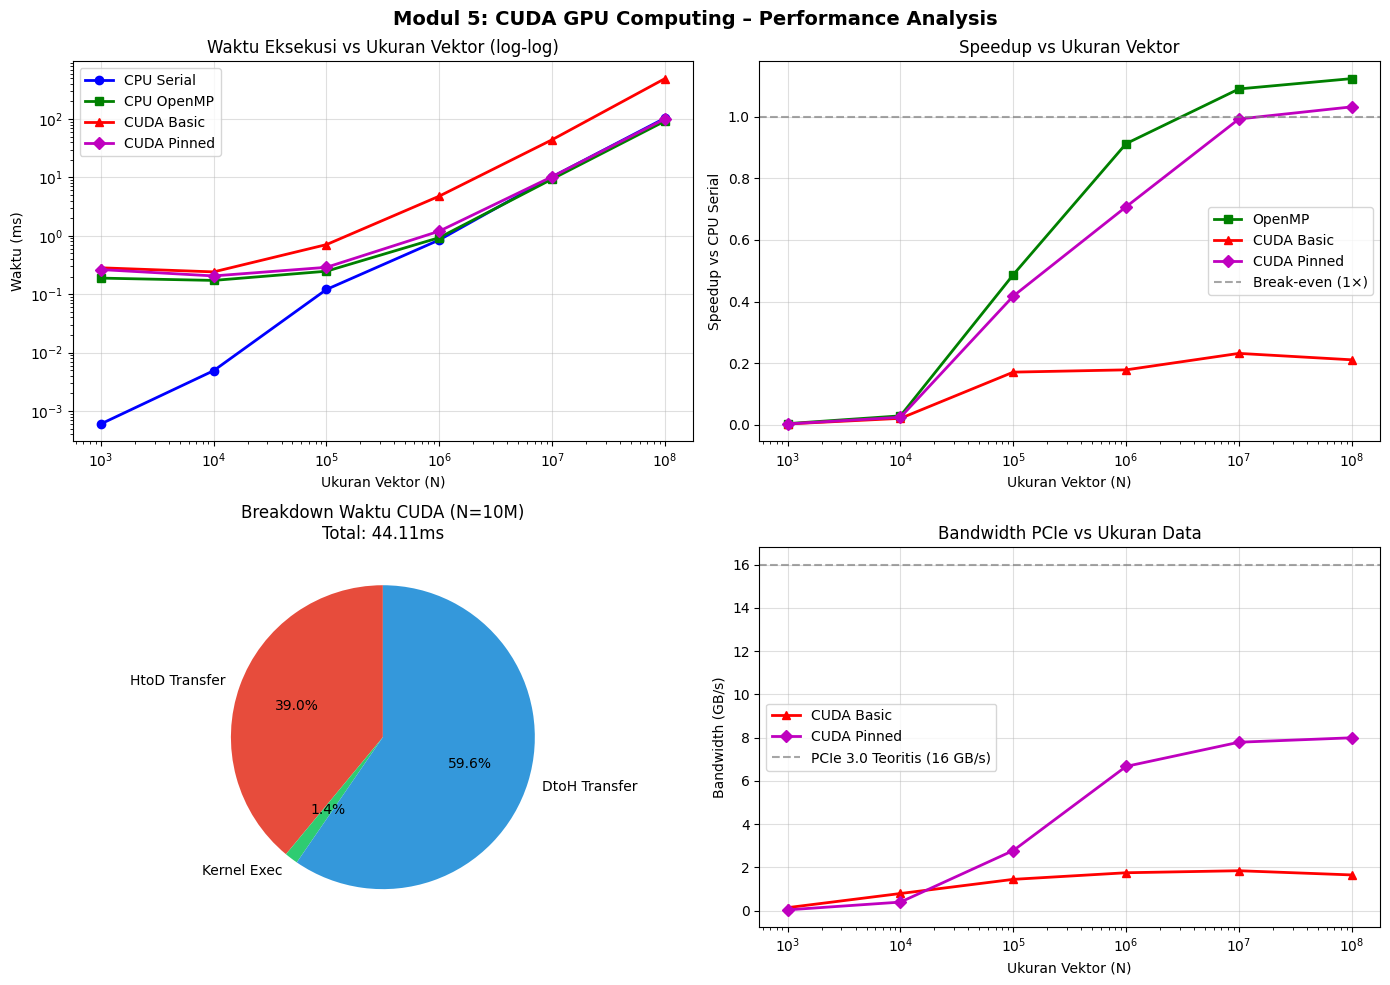

Grafik disimpan ke cuda_files/performance_analysis.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sizes_k = [f'{n//1000}K' if n<1e6 else f'{n//1000000}M' for n in df['N']]

# Grafik 1: Waktu Eksekusi (log scale)
ax = axes[0,0]
ax.loglog(df['N'], df['cpu_ms'],    'b-o', label='CPU Serial',  linewidth=2)
ax.loglog(df['N'], df['omp_ms'],    'g-s', label='CPU OpenMP',  linewidth=2)
ax.loglog(df['N'], df['cuda_total'],'r-^', label='CUDA Basic',  linewidth=2)
ax.loglog(df['N'], df['pinned_total'],'m-D',label='CUDA Pinned',linewidth=2)
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Waktu (ms)')
ax.set_title('Waktu Eksekusi vs Ukuran Vektor (log-log)'); ax.legend(); ax.grid(True,alpha=0.4)

# Grafik 2: Speedup vs CPU Serial
ax = axes[0,1]
ax.semilogx(df['N'], df['speedup_omp'],   'g-s', label='OpenMP',      linewidth=2)
ax.semilogx(df['N'], df['speedup_cuda'],  'r-^', label='CUDA Basic',  linewidth=2)
ax.semilogx(df['N'], df['speedup_pinned'],'m-D', label='CUDA Pinned', linewidth=2)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label='Break-even (1×)')
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Speedup vs CPU Serial')
ax.set_title('Speedup vs Ukuran Vektor'); ax.legend(); ax.grid(True,alpha=0.4)

# Grafik 3: CUDA Breakdown (10M elemen)
ax = axes[1,0]
row10m = df[df['N']==10_000_000].iloc[0]
labels_b = ['HtoD Transfer','Kernel Exec','DtoH Transfer']
vals_b = [row10m['cuda_htod'], row10m['cuda_kernel'], row10m['cuda_dtoh']]
colors_b = ['#E74C3C','#2ECC71','#3498DB']
wedges,texts,autotexts = ax.pie(vals_b, labels=labels_b, colors=colors_b,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize':10})
ax.set_title(f'Breakdown Waktu CUDA (N=10M)\nTotal: {row10m["cuda_total"]:.2f}ms')

# Grafik 4: Bandwidth PCIe
ax = axes[1,1]
ax.semilogx(df['N'], df['pcie_bw_cuda'],   'r-^', label='CUDA Basic',  linewidth=2)
ax.semilogx(df['N'], df['pcie_bw_pinned'], 'm-D', label='CUDA Pinned', linewidth=2)
ax.axhline(y=16, color='gray', linestyle='--', alpha=0.7, label='PCIe 3.0 Teoritis (16 GB/s)')
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Bandwidth (GB/s)')
ax.set_title('Bandwidth PCIe vs Ukuran Data'); ax.legend(); ax.grid(True,alpha=0.4)

plt.suptitle('Modul 5: CUDA GPU Computing – Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cuda_files/performance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan ke cuda_files/performance_analysis.png')


## Langkah 8: Eksperimen Konfigurasi Thread per Block

TPB=   32: kernel=1.1844ms  total=43.8139ms
TPB=   64: kernel=0.6412ms  total=48.3763ms
TPB=  128: kernel=0.6475ms  total=59.7719ms
TPB=  256: kernel=0.6029ms  total=43.3859ms
TPB=  512: kernel=0.6076ms  total=43.6593ms
TPB= 1024: kernel=0.6119ms  total=44.2397ms

=== Tabel Thread per Block ===
 ThreadsPerBlock  Blocks  Kernel_ms  Total_ms
              32  312500     1.1844   43.8139
              64  156250     0.6412   48.3763
             128   78125     0.6475   59.7719
             256   39063     0.6029   43.3859
             512   19532     0.6076   43.6593
            1024    9766     0.6119   44.2397


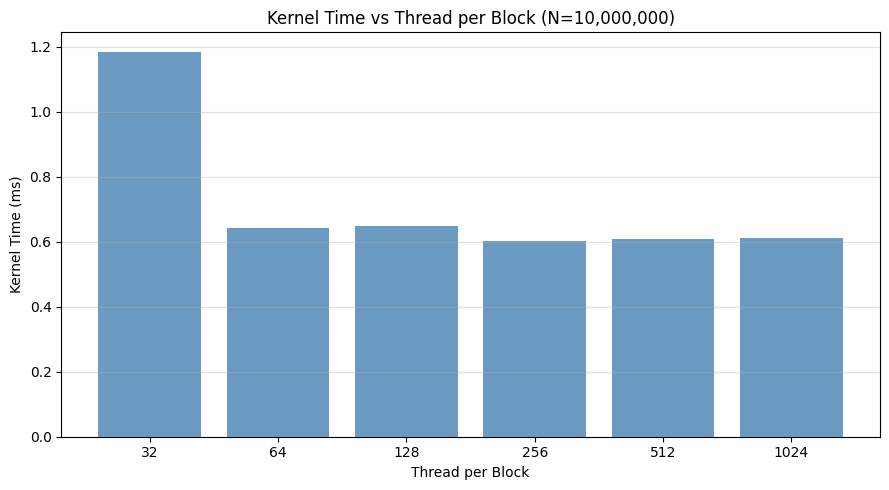

In [ ]:
tpb_configs = [32, 64, 128, 256, 512, 1024]
N_test = 10_000_000
tpb_results = []

for tpb in tpb_configs:
    r = subprocess.run(f'./cuda_files/vec_cuda {N_test} {tpb}',
                       shell=True, capture_output=True, text=True)
    d = parse_cuda(r.stdout)
    tpb_results.append({
        'ThreadsPerBlock': tpb,
        'Blocks'         : int(d.get('BLOCKS', 0)),
        'Kernel_ms'      : float(d.get('KERNEL',0)),
        'Total_ms'       : float(d.get('TOTAL',0))
    })
    print(f'TPB={tpb:5d}: kernel={float(d.get("KERNEL",0)):.4f}ms  total={float(d.get("TOTAL",0)):.4f}ms')

df_tpb = pd.DataFrame(tpb_results)
print('\n=== Tabel Thread per Block ===')
print(df_tpb.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(range(len(tpb_configs)), df_tpb['Kernel_ms'], color='steelblue', alpha=0.8)
ax.set_xticks(range(len(tpb_configs)))
ax.set_xticklabels([str(t) for t in tpb_configs])
ax.set_xlabel('Thread per Block'); ax.set_ylabel('Kernel Time (ms)')
ax.set_title(f'Kernel Time vs Thread per Block (N={N_test:,})')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.savefig('cuda_files/tpb_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
